# PCHN63112 Workshop: Repeated Measures with Replication Example
In this example, we will examine building a mixed-effects model for repeated measurements when replications of the repeats are available. This will provide the opportunity for a more general covariance structure than we have seen in some of the previous repeated measurement examples.

## Loading Packages
We will start by loading all the packages that we need at the beginning. This will tidy-up the output, allow any messages or warnings to not clutter up the rest of the output and not bury any packages within the main body of the analysis. We also use `source()` on the file `plot-lme.R`. This needs to be in the current working directory and will bring the custom function `plot.lme()` into scope.

In [1]:
library('lattice')   # plotting functions
library('Matrix')    # covariance extraction and visualisation
library('nlme')      # mixed-effects modelling
library('car')       # Asymptotic ANOVA tests
library('emmeans')   # Follow-up tests
library('effects')   # Effects plots from the model
source('plot-lme.R') # custom plot.lme() function for making assumptions plots

Loading required package: carData
Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'
Use the command
    lattice::trellis.par.set(effectsTheme())
  to customize lattice options for effects plots.
See ?effectsTheme for details.


## The Rat Brain Data
The data we will use concern measurements of nucleotide activation from the brains of five male adult rats. These measurements were taken using autoradiography after treatment with the drug carbachol and after treatment with saline. Three brain regions were chosen for measurement: the *bed nucleus of the stria terminalis* (BST), the *lateral septum* (LS) and the *diagonal band of Broca* (VDB). The outcome variable represents the mean optical density measured in each brain region and interest primarily lies in the effect of carbachol on nucleotide activation.

Importantly, you do not need to understand the biology of any of this. In purely statistical terms, it does not matter *what* any of the variables mean precisely. We can just think of them generically as an *outcome* and *treatments* applied to different *units*. The actual theory behind any of the decisions in this experiment is the business of the biologists who performed it. We are just here to analyse it. This is part of the skill of applying general methods to different contexts.

The data are available to download from [here](https://websites.umich.edu/~bwest/chapter5.html). Once downloaded to the current working directory, the code below will read the data in and then print the values for the first two rats.

In [2]:
ratbrain <- read.table('rat_brain.dat', header=TRUE)
print(ratbrain[1:12,])

    animal treatment region activate
1  R111097         1      1   366.19
2  R111097         1      2   199.31
3  R111097         1      3   187.11
4  R111097         2      1   371.71
5  R111097         2      2   302.02
6  R111097         2      3   449.70
7  R111397         1      1   375.58
8  R111397         1      2   204.85
9  R111397         1      3   179.38
10 R111397         2      1   492.58
11 R111397         2      2   355.74
12 R111397         2      3   459.58


As this is already long-formatted, we just need to convert the relevant variables to factors. We also choose to relabel both `treatment` and `region` to make their meaning clearer.

In [3]:
ratbrain$treatment <- as.factor(ratbrain$treatment)
ratbrain$region    <- as.factor(ratbrain$region)
ratbrain$animal    <- as.factor(ratbrain$animal)

levels(ratbrain$treatment) <- c('Saline', 'Carbachol')
levels(ratbrain$region)    <- c('BST', 'LS', 'VDB')

We now just briefly summarise all the variables to check everything is in order.

In [4]:
summary(ratbrain)

     animal      treatment  region      activate    
 R100797:6   Saline   :15   BST:10   Min.   :179.4  
 R100997:6   Carbachol:15   LS :10   1st Qu.:261.4  
 R110597:6                  VDB:10   Median :406.6  
 R111097:6                           Mean   :402.1  
 R111397:6                           3rd Qu.:493.6  
                                     Max.   :727.0  

## Data Structure
Although we already know what structure these data have, we will run through the logic for completeness. 

Firstly, we need to determine our *unit of analysis*. In this example, our model is trying to explain nucleotide activation after application of different treatments in the *brains of rats*. The entities that our model is describing are *brains of rats*, so our units of analysis are the *rats* themselves (or the *rat brains* themselves, depending upon how you want to think of it).   

Secondly, we determine what each *row* of the long-formatted data represents in relation to the units of analysis. Examining the first few rows

In [5]:
head(ratbrain)

   animal treatment region activate
1 R111097    Saline    BST   366.19
2 R111097    Saline     LS   199.31
3 R111097    Saline    VDB   187.11
4 R111097 Carbachol    BST   371.71
5 R111097 Carbachol     LS   302.02
6 R111097 Carbachol    VDB   449.70

we can see that each row corresponds to a single unit (*rat*) measured *multiple times*. So these are either *repeated measurements* or *longitudinal* data. The difference lies in whether there is an explicit measurement of time here. As we can see, the different repeats are indexed by the levels of `region`, but not by any index of time. There is no sense of *order* in the repeats, nor any metric of the *gap* between measurements. As such, this is simply *repeated measurements*.

Finally, we need to determine whether there are any *clustering* variables that represent a higher-order dependency structure in these data. From the data description we know that there are no variables of this sort, but we can also see that this is true from the data alone. Examining the rows above, we can see that there are *no* variables that are *constant* within each rat. As such, there are no candidates for either *clustering* variables or *grouping* variables. The experiment is purely *within-subject*. Based on this, we can construct the following table of the *levels* of these data, using the guidance in the lesson

| **Data Type**    | **Repeated Measures** | 
|------------------|-----------------------|
| **Dataset**      | `ratbrain`            |
| **Level 1**      | Repeated measurements |
| **Level 2**      | *Rat*                 |
| **Level 3**      | -                     |

Despite no clustering existing here, we could *imagine* such a structure if this experiment were a multi-centre study, where the same measurements were taken using different rats at different labs around the country. In this case, *lab* could be a *clustering* variable, as it is conceivable that measurements from rats in the same lab may be dependent in some way (same scientists, same lab environment, same equipment, same living standards etc.) We do not have this here, but this situation is certainly *possible*. This would make these data *clustered repeated measurements*, with *lab* appearing at Level 3. This is not a type we have described, but which remains perfectly analysable using the examples you will see across these workshops.

## Model Building
To build a model of this dataset, we use the 3-step procedure outlined in the lesson. We assume at this point that the data has been investigated, wrangled, cleaned and ready for modelling.

### Step I: A Single Dependency Structure
We start by isolating a single dependency structure which, in this example, is a single *rat*. We choose the first rat in the dataset, who is indexed using `animal == 'R111097'`. Based on the summaries earlier, the data are fully balanced within each rat, so the particular rat chosen will not make a difference here. We subset the data below

In [6]:
ratbrain.1 <- subset(ratbrain, animal=='R111097')
print(ratbrain.1)

   animal treatment region activate
1 R111097    Saline    BST   366.19
2 R111097    Saline     LS   199.31
3 R111097    Saline    VDB   187.11
4 R111097 Carbachol    BST   371.71
5 R111097 Carbachol     LS   302.02
6 R111097 Carbachol    VDB   449.70


As indicated earlier, we have no grouping variables or higher-level clustering variables here. So, for this model, we only have the option of using `treatment` and `region` as predictors. For the moment, we will treat `region` only as an index of the replications within each level of `treatment`. We do this for simplicity, particularly to indicate more clearly how replications enter the model. We will come back to the possibility of using `region` later. For now, the data we will work with is

In [7]:
ratbrain.1 <- subset(ratbrain, animal=='R111097', select= -region)
print(ratbrain.1)

   animal treatment activate
1 R111097    Saline   366.19
2 R111097    Saline   199.31
3 R111097    Saline   187.11
4 R111097 Carbachol   371.71
5 R111097 Carbachol   302.02
6 R111097 Carbachol   449.70


Our basic model for a single rat is therefore

$$
y_{ij} = \mu + \alpha_{j} + \eta_{ij}
$$

where $i$ indexes the observation and $j$ indexes the treatment. To make things clearer we will use the data labels from now on, rather than generic notation. Our model is therefore

$$
\text{activate}_{ij} = \text{mean} + \text{treatment}_{j} + \eta_{ij}.
$$

We *could* check that this fits for this particular rat, but we leave this to one side. We can see that there are 3 measurements of each treatment and so we have no concerns about fitting this model.

### Step II: Expand to Multiple Structures
In our second step, we expand the model above to *multiple* rats. We index these using the same notation we used in the lesson, to make it clear which terms *belong* to a particular rat. We start with the most general case of allowing every term to vary by-rat, giving us

$$
\text{activate}^{(k)}_{ij} = \text{mean}^{(k)} + \text{treatment}^{(k)}_{j} + \eta^{(k)}_{ij}.
$$

We can now reason more carefully about the terms $\text{mean}^{(k)}$ and $\text{treatment}^{(k)}_{j}$. This can be done in a more *data-driven* fashion by plotting the data and reasoning about the patterns we can see. For now, we will stick to using the theoretical implications of our decisions, but we will see this alternative illustrated further below.

#### Random Intercept Decision
As mentioned in the lesson, the most basic form of mixed-effects model will always contain a *random intercept* term. There is often little sensible reason to drop this, unless we are retuning to the normal linear model with no dependencies. In this context, keeping $\text{mean}^{(k)}$ *random* encodes the idea that each rat is a random sample from a distribution of rats. Without this, the model would not consider each rat to be a random draw. In other words, we would be implying that we had *all* the rats we were interested in within this dataset. This *may* be justifiable in a case study of only a set of very specific individuals, but does not apply here. As such, we allow the term $\text{mean}^{(k)}$ to vary from rat-to-rat.

#### Random Slope Decision
In terms of $\text{treatment}^{(k)}_{j}$, we have more of a choice. Keeping this term *random* encodes the idea that the difference between carbachol and saline is specific to each individual rat. Depending upon their biology, the degree of activation difference between the two treatments will shift on a per-rat basis. In some rats, this difference may be very *small* and in others it may be much *larger*. If we had infinite samples of infinite rats, the treatment effect across rats would *not* converge on the same value. Instead, each rat would have its own individual treatment effect. In this sense, any deviations we see from the population value of treatment are not simply sampling noise, they reflect something fundamental about differences between the rats. 

The alternative is to set $\text{treatment}^{(k)}_{j}$ to be *fixed*. This would encode the idea that the difference between carbachol and saline is universal and does not depend upon a specific rat. This is a simple fact of biology. The treatment impacts the brain in exactly the same way, irrespective of the specific rat. Any variation we see is simply sampling noise due to imperfect measurement and has nothing to do with a given rat. If we had infinite samples of infinite rats, the treatment effect across rats would all converge on the same value. In other words, the specific rat does not matter.

As mentioned in the lesson, in cases where we are uncertain we can simply treat a term as *random* and then use model comparisons to see what the data suggests. In this case, it seems like keeping $\text{treatment}^{(k)}_{j}$ *random* is the more justifiable choice, but we can assess this using the data later. So, because we have no strong reason for *fixing* this term, we leave it as random. Because there are multiple measurements of each level of treatment within each rat, the data also supports fitting this model. As such, our final Level 1 model is

$$
\begin{alignat*}{1}
\text{Level 1} \\
    \text{activate}^{(k)}_{ij} &= \text{mean}^{(k)} + \text{treatment}^{(k)}_{j} + \eta^{(k)}_{ij}.
\end{alignat*}
$$

### Step III: Write the Higher-level Models
In our final step, we take our Level 1 model and we expand each of the terms at the next level of the hierarchy. As mentioned in the lesson, irrespective of whether we have chosen to make a term *fixed* or *random*, it is useful to keep the per-structure indexing. The decision around whether a term is *fixed* or *random* emerges in terms of whether the 2nd-level models have *random error* or not.

For the current example, we express 2nd-level models for both $\text{mean}^{(k)}$ and $\text{treatment}^{(k)}_{j}$. Because these terms are both treated as *random*, these models come from expressing each term as a *normal random variate* with a population-level mean effect and some variance

$$
\begin{alignat*}{1}
    \text{mean}^{(k)}          &\sim \mathcal{N}\left(\text{mean}, \sigma^{2}_{\text{mean}}\right) \\
    \text{treatment}^{(k)}_{j} &\sim \mathcal{N}\left(\text{treatment}_{j}, \sigma^{2}_{\text{treat}_{j}}\right),
\end{alignat*}
$$

which we re-write in *mean + error* format, to integrate into our general model specification. This gives

$$
\begin{alignat*}{1}
    \text{Level 1} \\
    \text{activate}^{(k)}_{ij} &= \text{mean}^{(k)} + \text{treatment}^{(k)}_{j} + \eta^{(k)}_{ij} \\
    \quad\\
    \text{Level 2} \\
    \text{mean}^{(k)}          &= \text{mean} + \xi^{(k)} \\
    \text{treatment}^{(k)}_{j} &= \text{treatment}_{j} + \phi^{(k)}_{j}
\end{alignat*}
$$

where the assumptions about the error terms are now 

$$
\begin{alignat*}{1}
    \text{Level 1} \\
    \eta^{(k)}_{ij} &\sim \mathcal{N}\left(0, \sigma^{2}_{\eta}\right) \\
    \quad\\
    \text{Level 2} \\
    \xi^{(k)} &\sim \mathcal{N}\left(0, \sigma^{2}_{\text{mean}}\right) \\
    \phi^{(k)}_{j} &\sim \mathcal{N}\left(0, \sigma^{2}_{\text{treat}_{j}}\right).
\end{alignat*}
$$

The only additional step is whether we have more variables to integrate into the Level 2 models of the mean and the treatment. This would require additional grouping or clustering variables in this dataset, which we do not have. So, at this point, our multilevel model specification is complete.

## Fitting the Model in `R`
In order to fit the multilevel model given above, we need to collapse it to mixed-effects form. Using the equalities at Level 2 and integrating them into Level 1, we get

$$
\text{activate}^{(k)}_{ij} = \text{mean} + \text{treatment}_{j} + \xi^{(k)} + \phi^{(k)}_{j} + \eta^{(k)}_{ij}.
$$

To see how to tell `lme()` about the random effects, we isolate the random components (i.e. the error terms)

$$
\xi^{(k)} + \phi^{(k)}_{j} + \eta^{(k)}_{ij}
$$

and remove the final errors, as they do not need to be explicitly specified

$$
\xi^{(k)} + \phi^{(k)}_{j}.
$$

If we now change the notation to make the conditional element of these terms clearer

$$
\xi + \phi_{j} | k
$$

we can easily translate this specification into `1 + treatment|animal`. This comes from the fact that $\xi$ is constant (it has no index), $\phi_{j}$ is indexed by $j$ which corresponds to `treatment` and $k$ is used to index individual rats and so becomes `animal`.

Our model is therefore

In [8]:
ratbrain.lme <- lme(fixed   = activate ~ 1 + treatment,
                    random  = ~ 1 + treatment|animal,
                    data    = ratbrain,
                    control = lmeControl(opt='optim')
)

print(ratbrain.lme)

Linear mixed-effects model fit by REML
  Data: ratbrain 
  Log-restricted-likelihood: -172.1075
  Fixed: activate ~ 1 + treatment 
       (Intercept) treatmentCarbachol 
          292.8480           218.5853 

Random effects:
 Formula: ~1 + treatment | animal
 Structure: General positive-definite, Log-Cholesky parametrization
                   StdDev   Corr  
(Intercept)        29.27835 (Intr)
treatmentCarbachol 70.46590 0.976 
Residual           91.67909       

Number of Observations: 30
Number of Groups: 5 


Notice that we had to change the optimiser here because the default failed to converge. Also notice that the random-effects structure has led to the estimation of *three* variances. One for the `animal` mean, one for the effect of `treatment` and one for the residuals. We can see the implications of this for the covariance structure using

          1         2         3         4         5         6
1 9262.2770  857.2216  857.2216  2871.272  2871.272  2871.272
2  857.2216 9262.2770  857.2216  2871.272  2871.272  2871.272
3  857.2216  857.2216 9262.2770  2871.272  2871.272  2871.272
4 2871.2716 2871.2716 2871.2716 18255.821  9850.765  9850.765
5 2871.2716 2871.2716 2871.2716  9850.765 18255.821  9850.765
6 2871.2716 2871.2716 2871.2716  9850.765  9850.765 18255.821


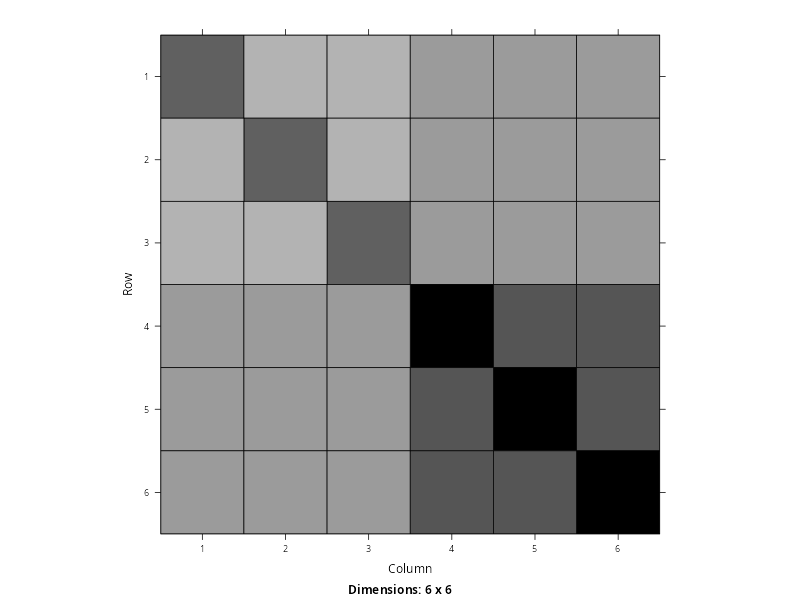

In [9]:
Sigma.1 <- getVarCov(ratbrain.lme, type='marginal', individual='R111097')$`R111097`
print(Sigma.1)
image(as(Sigma.1,'Matrix'))


In general, we can see that the measurements from an individual rat are all considered correlated. This structure is then further split into a block for the saline treatment (rows/columns 1-3) and a block for the carbachol treatment (rows/columns 4-6). All measurements within each level of treatment are considered equally-correlated, but these are allowed to differ for saline-saline, carbachol-carbachol and saline-carbachol pairs. Finally, the difference in shading between saline and carbachol implies that the variance of the saline treatment is *much lower* than the variance of the carbachol treatment. 

## Alternative Models
Before we get to checking assumptions and performing inference, it is a good idea to consider other model forms. Effectively, we want to get to our final model *before* performing these steps. This is both practical, as it prevents multiple confusing round of assumption checking and inference, and is also a guard against *bias*, particularly if we know the results of a given model specification. This sequence is therefore a self-imposed *protection* against being swayed by $p$-values more than the logic of building a sensible model.

### Including `region` in the Model
As discussed earlier, we left `region` out of our initial model for simplicity. However, we now consider whether to include this additional factor. 

In terms of reasoning, it would seem sensible to consider the fact that different parts of the brain may respond differently to the effects of `treatment`. These regions will differ in size and cytoarchitectural composition which could easily impact the effectiveness of the treatment. Including `region` in our model would allow us to assess whether these brain region differ fundamentally in levels of `activation`, as well as allowing us to entertaining the possibility of a `treatment:region` interaction. This would provide further insight into whether the effectiveness of the treatment depends upon the brain region that is measured. For instance, the treatment may be more *targeted* compared to a *global* effect in the brain.

In order to integrate `region`, we go back to our Level 1 model of a single rat and entertain the following model

$$
\text{activate}_{ij} = \text{mean} + \text{region}_{i} + \text{treatment}_{j} + (\text{region} \times \text{treatment})_{ij} + \eta_{ij}
$$

where $i$ now indexes the *region*. Already, we can see a problem because the interaction term and the error-term have the same indices. This is something of a clue to a limitation in this model, but we will press on for the moment. If we now expand this model to multiple rats, we have

$$
\text{activate}^{(k)}_{ij} = \text{mean}^{(k)} + \text{region}^{(k)}_{i} + \text{treatment}^{(k)}_{j} + (\text{region} \times \text{treatment})^{(k)}_{ij} + \eta^{(k)}_{ij}.
$$

So, we now have decisions to make about whether 4 terms should be random or not. We will stick to treating both $\text{mean}^{(k)}$ and $\text{treatment}^{(k)}_{j}$ as random, given the discussions from earlier. So, our new decision is whether to treat $\text{region}^{(k)}_{i}$ as random. If we do, this would suggest that differences in activation between brain regions are *rat-specific*. For instance, in one rat the activation of the BST is larger than the VDB, whereas in another rat the regions are the other way around. 

We can reason about whether this is sensible assumption, but we can also look at the data and see what it suggests. This is a more general *data-driven* approach that can be used to make decisions about *all* the random effects. This is an alternative to simply trying to reason about each term.

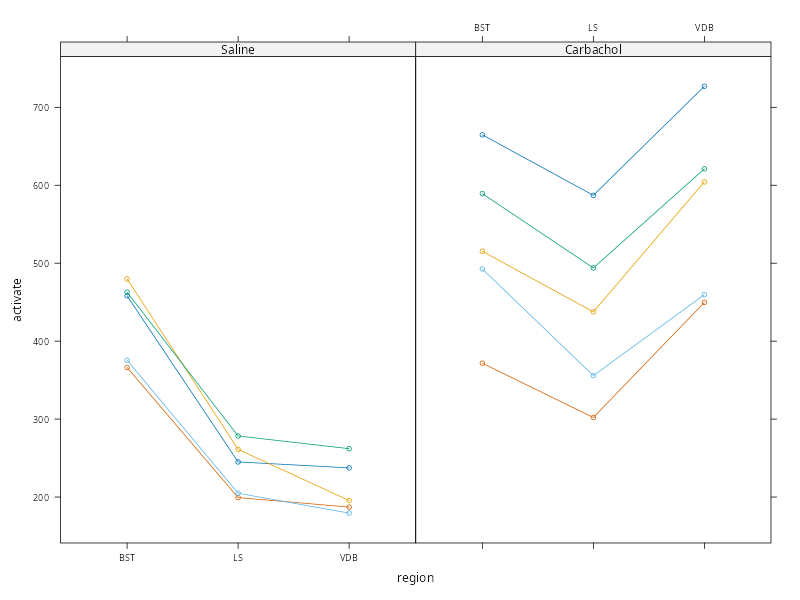

In [10]:
xyplot(
  activate ~ region|treatment, # x-axis=region, panel=treatment
  groups = animal,             # separate lines per-animal
  data   = ratbrain,           # data
  type   = "b"                 # lines with points
)

Notice that the pattern across the brain regions within each panel is very similar across the rats. For instance, under carbachol, notice that the v-shape is largely the *same* for each rat. This suggest that the differences in measurement between these regions does not differ on a per-rat basis. The slight differences we see could simply be sampling error. There is not enough variation here to suggest that this is something that differs fundamentally from rat-to-rat. As such, this suggests that `region` can defensibly be treated as a *fixed-effect*.

On the back of this decision, it makes little sense to treat $(\text{region} \times \text{treatment})^{(k)}_{ij}$ as *random*, given that one of the terms involved in the interaction is *fixed*. The interaction can be seen in the plot above because the pattern of responses across the regions is *different* between the two panels. One is L-shaped and one is V-shaped. If the lines were V-shaped in both panels, there would be no interaction, just a main effect. If we suggest that the interaction *differs* across rats, then there would need to be a different change in shape between the two panels for each rat. Perhaps one rat has a flat line in one panel and a V-shape in the other. Perhaps another rat has an L-shaped pattern in both panels. This then implies that the shapes within a single panel *must* be different between the rats, but this cannot be the case if `region` is fixed. As such, unless *both* terms are random, it makes limited sense to try and include a random interaction. In addition, even if we had treated `region` as random, the data would not support inclusion of the interaction term in the random effects. Because of all of this, we will also treat `region:treatment` as a *fixed-effect*.

Taking all this together, our model that includes `region` is

$$
\begin{alignat*}{1}
    \text{Level 1} \\
    \text{activate}^{(k)}_{ij} &= \text{mean}^{(k)}  + \text{region}^{(k)}_{i} + \text{treatment}^{(k)}_{j} + (\text{region} \times \text{treatment})^{(k)}_{ij} + \eta^{(k)}_{ij} \\
    \quad\\
    \text{Level 2} \\
    \text{mean}^{(k)}          &= \text{mean} + \xi^{(k)} \\
    \text{region}^{(k)}_{i}    &= \text{region}_{i} \\
    \text{treatment}^{(k)}_{j} &= \text{treatment}_{j} + \phi^{(k)}_{j} \\
    (\text{region} \times \text{treatment})^{(k)}_{ij} &= (\text{region} \times \text{treatment})_{ij},
\end{alignat*}
$$

noticing that those terms that are *fixed* do not contain random error terms in their 2nd-level models. We could also express this by collapsing those fixed terms back into Level 1

$$
\begin{alignat*}{1}
    \text{Level 1} \\
    \text{activate}^{(k)}_{ij} &= \text{mean}^{(k)}  + \text{region}_{i} + \text{treatment}^{(k)}_{j} + (\text{region} \times \text{treatment})_{ij} + \eta^{(k)}_{ij} \\
    \quad\\
    \text{Level 2} \\
    \text{mean}^{(k)}          &= \text{mean} + \xi^{(k)} \\
    \text{treatment}^{(k)}_{j} &= \text{treatment}_{j} + \phi^{(k)}_{j}.
\end{alignat*}
$$

The mixed-effects specification is then

$$
\text{activate}^{(k)}_{ij} = \text{mean} + \text{region}_{i} +\text{treatment}_{j} + (\text{region} \times \text{treatment})_{ij} + \xi^{(k)} + \phi^{(k)}_{j} + \eta^{(k)}_{ij},
$$

where the random effects have remained the same as our earlier model. Indeed, the only change here is that $\text{region}_{i}$ and $(\text{region} \times \text{treatment})_{ij}$ have entered the mean function. We can specify this in `R` using

In [11]:
ratbrain.lme <- lme(fixed   = activate ~ 1 + treatment*region,
                    random  = ~ 1 + treatment|animal,
                    data    = ratbrain,
                    control = lmeControl(opt='optim')
)

print(ratbrain.lme)

Linear mixed-effects model fit by REML
  Data: ratbrain 
  Log-restricted-likelihood: -124.5952
  Fixed: activate ~ 1 + treatment * region 
                 (Intercept)           treatmentCarbachol 
                     428.506                       98.204 
                    regionLS                    regionVDB 
                    -190.762                     -216.212 
 treatmentCarbachol:regionLS treatmentCarbachol:regionVDB 
                      99.322                      261.822 

Random effects:
 Formula: ~1 + treatment | animal
 Structure: General positive-definite, Log-Cholesky parametrization
                   StdDev   Corr  
(Intercept)        35.83670 (Intr)
treatmentCarbachol 79.82041 0.801 
Residual           23.21427       

Number of Observations: 30
Number of Groups: 5 


We can also re-examine the covariance structure. It will not differ in its pattern, because the random-effects have not changed, but it will differ in its values because the mean function is now different.

         1        2        3         4         5         6
1 1823.172 1284.269 1284.269  3575.472  3575.472  3575.472
2 1284.269 1823.172 1284.269  3575.472  3575.472  3575.472
3 1284.269 1284.269 1823.172  3575.472  3575.472  3575.472
4 3575.472 3575.472 3575.472 12776.875 12237.973 12237.973
5 3575.472 3575.472 3575.472 12237.973 12776.875 12237.973
6 3575.472 3575.472 3575.472 12237.973 12237.973 12776.875


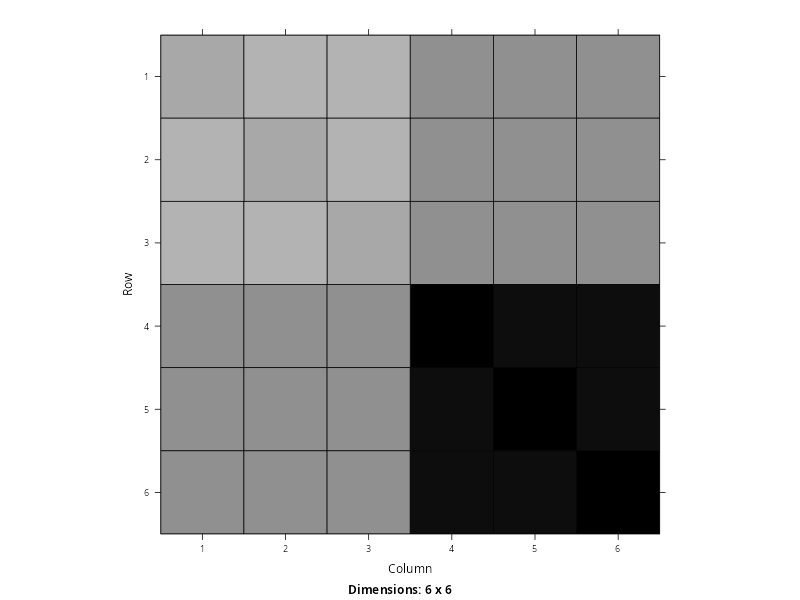

In [12]:
Sigma.1 <- getVarCov(ratbrain.lme, type='marginal', individual='R111097')$`R111097`
print(Sigma.1)
image(as(Sigma.1,'Matrix'))

We can see that the block associated with the carbachol treatment is *very dark* because the variance in this treatment is *much higher* relative to the saline treatment. We can see this in the plot from earlier where the lines were very spread out under carbachol and much closer together under saline.

### Simplifying the Random Effects
Now that we have our fixed-effects and random-effects sorted, we could leave the model as it is. However, it is always worth checking where a more *parsimonious* model may be as equally effective. Generally, this comes down to seeing whether a *simpler* random effects structure is justifiable. As present we are using `1 + treatment|animal`, so our decision is whether we keep this structure or whether we could simplify it to `1|animal`. Although we reasoned earlier that the effect of `treatment` could differ across rats, the plot from earlier did not suggest that this was particularly strong. All the lines in the left panel seemed to increase by a similar amount in the right panel. The order of the lines was largely similar as well. So there is reason to think that `treatment` could be treated simply as *fixed*. 

In order to check, we compare the two possible structures below. Of importance is setting `method='ML'` to make sure this comparison is *meaningful*. In addition, rather than requesting the full model comparison output of `anova()`, we just work with the BIC by using the `BIC()` function.

In [13]:
ratbrain.lme.null <- lme(activate ~ 1 + treatment*region, random= ~ 1|animal,             data=ratbrain, method='ML', control=lmeControl(opt='optim'))
ratbrain.lme.full <- lme(activate ~ 1 + treatment*region, random= ~ 1 + treatment|animal, data=ratbrain, method='ML', control=lmeControl(opt='optim'))

mod.comp <- BIC(ratbrain.lme.null, ratbrain.lme.full)
print(mod.comp)

                  df      BIC
ratbrain.lme.null  8 352.5472
ratbrain.lme.full 10 326.7349


The change in BIC between these models is

In [14]:
abs(mod.comp$BIC[1] - mod.comp$BIC[2])

[1] 25.81224

which sits in the category of *very strong evidence favouring the lower-BIC model*. So, even though the model that includes `treatment` as a random-effect has *more* parameters (the `df` shown in the comparison), it has a *lower* BIC. That means that these extra parameters are *justifiable* in terms of capturing something useful in the data. We therefore choose to continue with

In [15]:
ratbrain.lme <- lme(fixed   = activate ~ 1 + treatment*region,
                    random  = ~ 1 + treatment|animal,
                    data    = ratbrain,
                    control = lmeControl(opt='optim')
)

### Additional Variance Structures
As a final check, we should consider whether there are any additional variance structures that we may wish to capture using the `weights=` option. Looking back at the covariance structure from earlier, we can see that the variance of the two different treatments is already captured by the random effects. However, we may have cause to think that variance differences exist between regions. It is not wholly implausible that some regions are fundamentally more variable in their measurements of `activation` than others. So, as a final step, we choose to check this by comparing models with and without a `weights` option.

In [16]:
ratbrain.lme.null <- lme(activate ~ 1 + treatment*region, random= ~ 1 + treatment|animal,                                     data=ratbrain, method='ML', control=lmeControl(opt='optim'))
ratbrain.lme.full <- lme(activate ~ 1 + treatment*region, random= ~ 1 + treatment|animal, weights=varIdent(form= ~ 1|region), data=ratbrain, method='ML', control=lmeControl(opt='optim'))

mod.comp <- BIC(ratbrain.lme.null, ratbrain.lme.full)
print(mod.comp)

                  df      BIC
ratbrain.lme.null 10 326.7349
ratbrain.lme.full 12 326.1652


The change in BIC is

In [17]:
abs(mod.comp$BIC[1] - mod.comp$BIC[2])

[1] 0.5697309

which suggests that there is *very little evidence* in favour of the model with the *lower* BIC. As such, this additional complication is *not supported* by the data and we arrive at our final model of

In [18]:
ratbrain.lme <- lme(fixed   = activate ~ 1 + treatment*region,
                    random  = ~ 1 + treatment|animal,
                    data    = ratbrain,
                    control = lmeControl(opt='optim')
)

## Checking Assumptions
To check the assumptions, we will use the custom function `plot.lme()`, which we brought into scope at the beginning of the analysis. This results in the following plots.

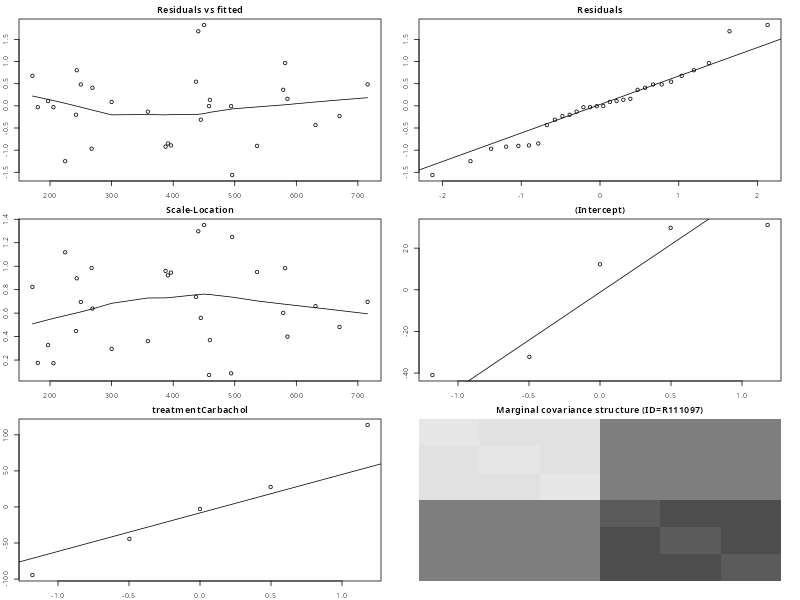

In [19]:
plot.lme(ratbrain.lme, vcov.id='R111097')

There is nothing here of immediate concern. There are no signs of missing variance structures and no signs of any outliers. The only element that is particularly difficult to assess is the normality of the random effects. However, this is never going to be reliable with only 5 dependency structures. So, unfortunately, we cannot really say either way whether this assumption is valid. We just need to press on, but should be acutely aware of how small the sample is at the level of individual rats when it comes to inference.

## Inference
As our final stop in this process, we turn our attention to inference on the fixed-effects. As usual, our process is to generate omnibus tests using `Anova()`, plot anything of note using `plot(effect(...))` and follow-up any tests that need to be followed-up using `emmeans()`.

We start with the ANOVA table

In [20]:
Anova(ratbrain.lme)

Analysis of Deviance Table (Type II tests)

Response: activate
                   Chisq Df Pr(>Chisq)    
treatment         35.495  1  2.558e-09 ***
region           187.414  2  < 2.2e-16 ***
treatment:region 162.092  2  < 2.2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

where there is a strong suggestion of a 2-way interaction. Even though this is asymptotic, the $p$-value is so small that it seems unlikely this could be a function of small-sample bias alone. As such, we choose to continue by plotting this effect

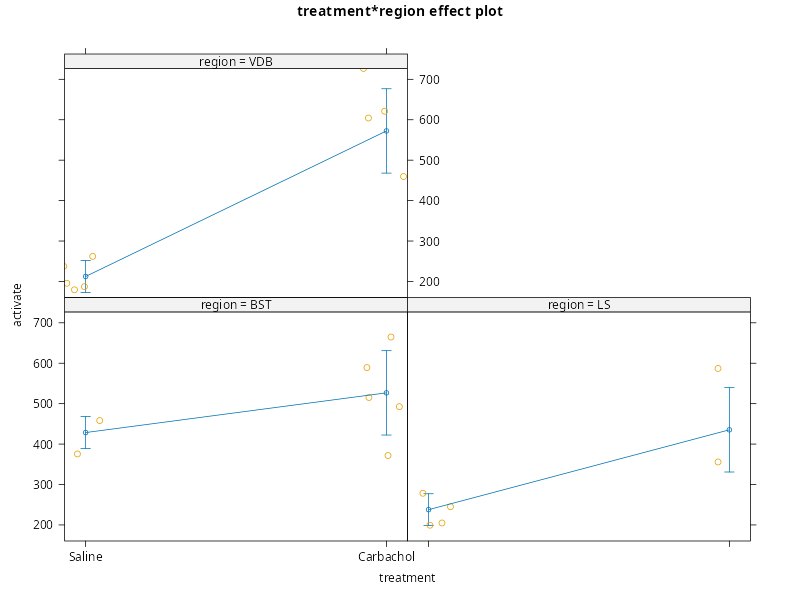

In [21]:
plot(effect('treatment:region', ratbrain.lme, residuals=TRUE), x.var='treatment', partial.residuals=list(smooth=FALSE))

So it appears as if the effect of `treatment` is much larger in the VDB than the other two regions. Both LS and BST are similar, with the effect in BST slightly more subtle than in LS. As a final step, we run some comparisons using `emmeans()`.

In [22]:
emm <- emmeans(ratbrain.lme, pairwise ~ treatment|region, mode='asymptotic', adjust='holm')
print(emm$contrasts)

region = BST:
 contrast           estimate   SE  df z.ratio p.value
 Saline - Carbachol    -98.2 38.6 Inf  -2.544  0.0110

region = LS:
 contrast           estimate   SE  df z.ratio p.value
 Saline - Carbachol   -197.5 38.6 Inf  -5.117  <.0001

region = VDB:
 contrast           estimate   SE  df z.ratio p.value
 Saline - Carbachol   -360.0 38.6 Inf  -9.328  <.0001

Degrees-of-freedom method: fixed 


This largely confirms our suspicions that `treatment` is most effective in the VDB, followed by LS and finally BST. All 3 are significant, though we may exercise some caution around the BST effect, given the smaller magnitude of effect, the asymptotic nature of the test and our small sample.